<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/6_6_GO_KEGG_Enrichment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1 — Functional Enrichment Analysis: GO & KEGG Pathway Analysis

**Course:** Applied Bioinformatics / Computational Biology
**Duration:** ~90 minutes
**Level:** Intermediate

## Learning Objectives
By the end of this lab you will be able to:
1. Explain the structure of the Gene Ontology (Biological Process, Molecular Function, Cellular Component) and the organisation of the KEGG pathway database.
2. Take a list of differentially expressed genes (DEGs) and run **over-representation analysis (ORA)** against GO and KEGG.
3. Interpret enrichment statistics (p-value, adjusted p-value / FDR, gene ratio, combined score).
4. Produce publication-style enrichment plots (bar plot, dot plot).
5. Critically discuss the biological meaning of the top enriched terms for a case study in **BRAF-mutant colorectal cancer (CRC)**.

## Scenario
You are given a shortlist of genes that came out of a differential expression analysis comparing **BRAF-V600E mutant colorectal tumours vs. BRAF-wild-type tumours** (the kind of gene list a DESeq2/edgeR pipeline would hand you). Your job as the bioinformatics analyst is to work out *what biological processes and pathways* this gene list points to, so the wet-lab team knows what to validate next.

> **Note on the data:** the gene list below is a small, hand-curated illustrative set built from genes that recur in the BRAF/MAPK–CRC literature (e.g. *BRAF, KRAS, MAP2K1, EGFR, PIK3CA, PTEN, TP53, APC, MLH1, MSH2, CCND1, MYC, VEGFA, MMP9*, etc.). It is **for teaching purposes only** — treat it as a stand-in for a real DESeq2 results table, not as a validated finding.


## 1. Environment Setup

We use **gseapy** (a Python wrapper around Enrichr) for GO/KEGG over-representation analysis, plus `pandas`/`matplotlib` for data handling and plotting. gseapy queries the Enrichr web service, so this cell needs an active internet connection (works out-of-the-box on Google Colab).

In [1]:
# Run once per session
!pip install -q gseapy mygene matplotlib seaborn --upgrade

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp

sns.set_theme(style="whitegrid", font_scale=1.05)
print("gseapy version:", gp.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 1.1 MB/s eta 0:00:00
gseapy version: 1.3.1


## 2. Load the Differential Expression Gene List

In a real project this table would come straight out of DESeq2/edgeR/limma (`results()` object exported to CSV). Here we construct it directly so the notebook is fully self-contained and reproducible without any external download.

In [2]:
# Illustrative DEG table: BRAF-mutant vs BRAF-WT colorectal tumours
# (log2FC > 0  => up-regulated in BRAF-mutant tumours)
deg_data = {
    "gene_symbol": ["BRAF","KRAS","NRAS","MAP2K1","MAPK1","MAPK3","EGFR","ERBB2",
                     "PIK3CA","PTEN","AKT1","MTOR","TP53","APC","CTNNB1","MLH1",
                     "MSH2","MSH6","PMS2","CCND1","MYC","VEGFA","MMP9","MMP2",
                     "CDKN2A","SMAD4","FBXW7","TGFBR2","CDH1","JUN"],
    "log2FoldChange": [3.1, 1.8, 0.4, 2.4, 2.0, 1.6, -1.9, -0.8,
                        1.2, -2.1, 1.4, 1.1, -0.6, -1.5, 0.9, -2.6,
                        -2.3, -1.8, -1.4, 2.8, 2.2, 2.5, 3.0, 1.7,
                        -1.9, -1.2, -1.6, -1.1, -1.3, 1.5],
    "padj": [1e-9, 3e-6, 0.21, 2e-7, 4e-6, 1e-4, 3e-5, 0.08,
             1e-3, 5e-6, 2e-3, 4e-3, 0.06, 2e-4, 1e-2, 3e-7,
             1e-6, 4e-5, 2e-3, 1e-8, 5e-7, 2e-6, 1e-5, 3e-3,
             4e-5, 6e-3, 2e-4, 1e-2, 3e-3, 4e-2],
}
deg_df = pd.DataFrame(deg_data)
deg_df.head(10)


,gene_symbol,log2FoldChange,padj
0,BRAF,3.1,1.000000e-09
1,KRAS,1.8,3.000000e-06
2,NRAS,0.4,2.100000e-01
3,MAP2K1,2.4,2.000000e-07
4,MAPK1,2.0,4.000000e-06
5,MAPK3,1.6,1.000000e-04
6,EGFR,-1.9,3.000000e-05
7,ERBB2,-0.8,8.000000e-02
8,PIK3CA,1.2,1.000000e-03
9,PTEN,-2.1,5.000000e-06


## 3. Filter for Significant DEGs

Standard thresholds: adjusted p-value (`padj`) < 0.05 and |log2 fold-change| > 1. Split into **up-regulated** and **down-regulated** sets — biologically these often point to different processes, so it's good practice to enrich them separately as well as together.

In [3]:
sig_df = deg_df[(deg_df["padj"] < 0.05) & (deg_df["log2FoldChange"].abs() > 1)].copy()
up_genes   = sig_df.loc[sig_df["log2FoldChange"] > 0, "gene_symbol"].tolist()
down_genes = sig_df.loc[sig_df["log2FoldChange"] < 0, "gene_symbol"].tolist()
all_sig_genes = sig_df["gene_symbol"].tolist()

print(f"Total significant DEGs : {len(all_sig_genes)}")
print(f"Up-regulated           : {len(up_genes)}  -> {up_genes}")
print(f"Down-regulated         : {len(down_genes)}  -> {down_genes}")


Total significant DEGs : 26
Up-regulated           : 14  -> ['BRAF', 'KRAS', 'MAP2K1', 'MAPK1', 'MAPK3', 'PIK3CA', 'AKT1', 'MTOR', 'CCND1', 'MYC', 'VEGFA', 'MMP9', 'MMP2', 'JUN']
Down-regulated         : 12  -> ['EGFR', 'PTEN', 'APC', 'MLH1', 'MSH2', 'MSH6', 'PMS2', 'CDKN2A', 'SMAD4', 'FBXW7', 'TGFBR2', 'CDH1']


## 4. GO Enrichment Analysis (Biological Process, Molecular Function, Cellular Component)

We run over-representation analysis against three Enrichr GO gene-set libraries:
- `GO_Biological_Process_2023`
- `GO_Molecular_Function_2023`
- `GO_Cellular_Component_2023`

`gseapy.enrichr()` submits the gene list to the Enrichr web API and returns a table of enriched terms with p-values, adjusted p-values, and the overlapping genes.

In [5]:
import time # Import the time module for delays

go_libraries = [
    "GO_Biological_Process_2023",
    "GO_Molecular_Function_2023",
    "GO_Cellular_Component_2023",
]

go_results = {}
for lib in go_libraries:
    enr = gp.enrichr(
        gene_list=all_sig_genes,
        gene_sets=lib,
        organism="human",
        outdir=None,          # don't write files to disk, keep result in memory
    )
    go_results[lib] = enr.results.sort_values("Adjusted P-value")
    print(f"{lib}: {len(go_results[lib])} terms returned")
    time.sleep(1) # Add a 1-second delay between requests to avoid rate-limiting

go_results["GO_Biological_Process_2023"].head(10)[
    ["Term", "Overlap", "P-value", "Adjusted P-value", "Genes"]
]


GO_Biological_Process_2023: 917 terms returned
GO_Molecular_Function_2023: 133 terms returned
GO_Cellular_Component_2023: 79 terms returned


,Term,Overlap,P-value,Adjusted P-value,Genes
0,Cellular Response To Cadmium Ion (GO:0071276),6/22,1.906845e-13,1.748576e-10,JUN;AKT1;MAPK1;MMP9;EGFR;MAPK3
1,Positive Regulation Of Protein Phosphorylation...,11/377,5.536715e-13,2.538584e-10,SMAD4;CCND1;MAPK1;AKT1;BRAF;KRAS;MMP9;EGFR;MAP...
2,Cellular Response To Metal Ion (GO:0071248),8/135,4.927263e-12,1.506100e-09,JUN;CDH1;MAPK1;AKT1;BRAF;MMP9;EGFR;MAPK3
3,Response To Cadmium Ion (GO:0046686),5/21,4.950892e-11,1.134992e-08,JUN;MAPK1;MMP9;EGFR;MAPK3
4,Response To Reactive Oxygen Species (GO:0000302),6/66,2.236330e-10,4.101429e-08,JUN;MAPK1;AKT1;MMP9;EGFR;MAPK3
5,Cellular Response To Reactive Oxygen Species (...,6/73,4.164855e-10,6.365287e-08,JUN;MAPK1;AKT1;MMP9;EGFR;MAPK3
6,Regulation Of Cyclin-Dependent Protein Serine/...,6/79,6.765724e-10,8.863099e-08,CCND1;APC;CDKN2A;PTEN;AKT1;EGFR
7,Regulation Of Protein Phosphorylation (GO:0001...,8/265,1.086208e-09,1.126813e-07,CCND1;PTEN;AKT1;KRAS;MMP9;EGFR;MAPK3;VEGFA
8,Regulation Of Cell Population Proliferation (G...,11/766,1.105923e-09,1.126813e-07,MAP2K1;JUN;APC;CDKN2A;MYC;PTEN;AKT1;KRAS;EGFR;...
9,Cellular Response To Oxygen-Containing Compoun...,9/406,1.233577e-09,1.131190e-07,JUN;CDH1;MAPK1;AKT1;BRAF;MMP9;EGFR;MTOR;MAPK3


### 4.1 Visualise the Top Biological Process Terms

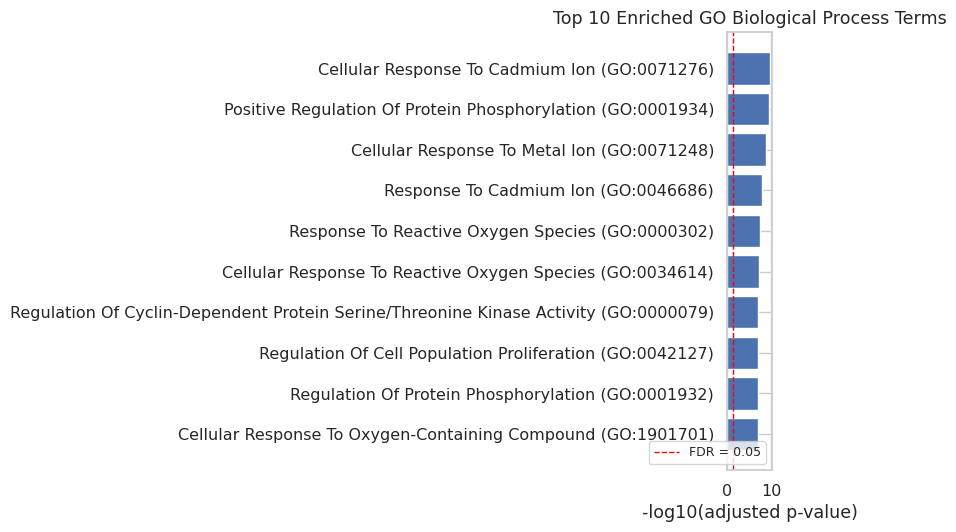

In [6]:
def barplot_enrichment(res_df, title, top_n=10, ax=None):
    df = res_df.sort_values("Adjusted P-value").head(top_n).copy()
    df["-log10(FDR)"] = -np.log10(df["Adjusted P-value"].clip(lower=1e-300))
    df = df.sort_values("-log10(FDR)")
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 0.45 * top_n + 1))
    ax.barh(df["Term"], df["-log10(FDR)"], color="#4C72B0")
    ax.set_xlabel("-log10(adjusted p-value)")
    ax.set_title(title)
    ax.axvline(-np.log10(0.05), color="red", linestyle="--", linewidth=1, label="FDR = 0.05")
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    return ax

barplot_enrichment(go_results["GO_Biological_Process_2023"], "Top 10 Enriched GO Biological Process Terms")
plt.show()


### 4.2 Dot Plot — Gene Ratio vs. Significance

A dot plot additionally encodes the **gene ratio** (fraction of your input genes found in the term) as dot size, alongside significance as colour — a very common figure style in enrichment papers.

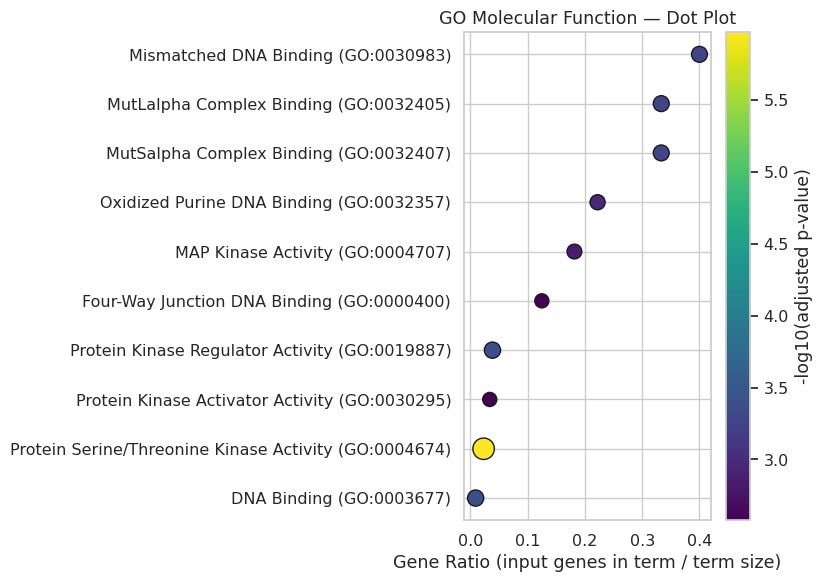

In [7]:
def dotplot_enrichment(res_df, title, top_n=10):
    df = res_df.sort_values("Adjusted P-value").head(top_n).copy()
    df["-log10(FDR)"] = -np.log10(df["Adjusted P-value"].clip(lower=1e-300))
    df["GeneRatio"] = df["Overlap"].apply(lambda x: eval(x.replace("/", "/")) if "/" not in "" else x)
    df["GeneRatio"] = df["Overlap"].apply(lambda x: int(x.split("/")[0]) / int(x.split("/")[1]))
    df = df.sort_values("GeneRatio")

    fig, ax = plt.subplots(figsize=(8, 0.5 * top_n + 1))
    sc = ax.scatter(df["GeneRatio"], df["Term"], s=df["-log10(FDR)"] * 40,
                     c=df["-log10(FDR)"], cmap="viridis", edgecolor="k")
    ax.set_xlabel("Gene Ratio (input genes in term / term size)")
    ax.set_title(title)
    cbar = plt.colorbar(sc)
    cbar.set_label("-log10(adjusted p-value)")
    plt.tight_layout()
    plt.show()

dotplot_enrichment(go_results["GO_Molecular_Function_2023"], "GO Molecular Function — Dot Plot")


## 5. KEGG Pathway Enrichment

Same workflow, different gene-set library: `KEGG_2021_Human`. KEGG groups genes into curated signalling and metabolic **pathways** rather than ontology terms — this is usually the most actionable output for wet-lab follow-up (e.g. "the MAPK signalling pathway is enriched" is directly testable with an inhibitor).

In [8]:
kegg_enr = gp.enrichr(
    gene_list=all_sig_genes,
    gene_sets="KEGG_2021_Human",
    organism="human",
    outdir=None,
)
kegg_res = kegg_enr.results.sort_values("Adjusted P-value")
kegg_res.head(10)[["Term", "Overlap", "P-value", "Adjusted P-value", "Genes"]]


,Term,Overlap,P-value,Adjusted P-value,Genes
0,Colorectal cancer,18/86,5.696921e-38,9.172042e-36,MAP2K1;SMAD4;JUN;BRAF;MLH1;EGFR;MTOR;TGFBR2;MS...
1,Pathways in cancer,24/531,2.776340e-36,2.234954e-34,MAP2K1;SMAD4;JUN;CDKN2A;MMP2;PTEN;BRAF;MLH1;MM...
2,Endometrial cancer,14/58,5.097277e-30,2.735539e-28,MAP2K1;PTEN;BRAF;MLH1;EGFR;CCND1;PIK3CA;APC;CD...
3,Bladder cancer,13/41,1.372097e-29,5.522691e-28,MAP2K1;CDKN2A;MMP2;BRAF;MMP9;EGFR;VEGFA;CCND1;...
4,Gastric cancer,16/149,1.957218e-28,6.302242e-27,MAP2K1;SMAD4;BRAF;MLH1;EGFR;MTOR;TGFBR2;CCND1;...
5,Pancreatic cancer,14/76,3.419924e-28,9.176797e-27,MAP2K1;SMAD4;CDKN2A;BRAF;EGFR;MTOR;VEGFA;TGFBR...
6,Hepatocellular carcinoma,16/168,1.459148e-27,3.356040e-26,MAP2K1;SMAD4;CDKN2A;PTEN;BRAF;EGFR;MTOR;TGFBR2...
7,Breast cancer,14/147,6.372791e-24,1.282524e-22,MAP2K1;JUN;PTEN;BRAF;EGFR;MTOR;CCND1;PIK3CA;AP...
8,Melanoma,12/72,1.672338e-23,2.991627e-22,MAP2K1;CCND1;PIK3CA;CDH1;CDKN2A;PTEN;MAPK1;AKT...
9,Glioma,12/75,2.838210e-23,4.569517e-22,MAP2K1;CCND1;PIK3CA;CDKN2A;PTEN;MAPK1;AKT1;BRA...


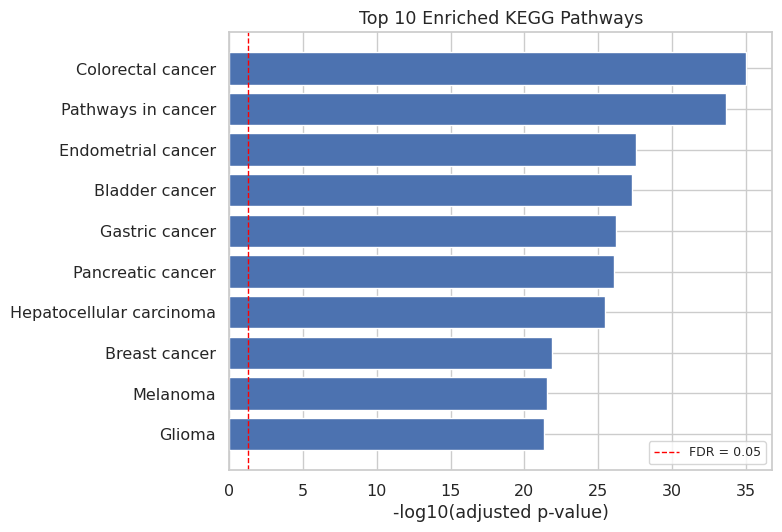

In [9]:
barplot_enrichment(kegg_res, "Top 10 Enriched KEGG Pathways")
plt.show()


## 6. Comparing Up- vs. Down-regulated Gene Sets Separately

Running enrichment on the full DEG list can blur the signal when up- and down-regulated genes point in different biological directions. Repeat the KEGG enrichment separately for `up_genes` and `down_genes`.

Top pathway UP in BRAF-mutant tumours:   Proteoglycans in cancer
Top pathway DOWN in BRAF-mutant tumours: Pathways in cancer


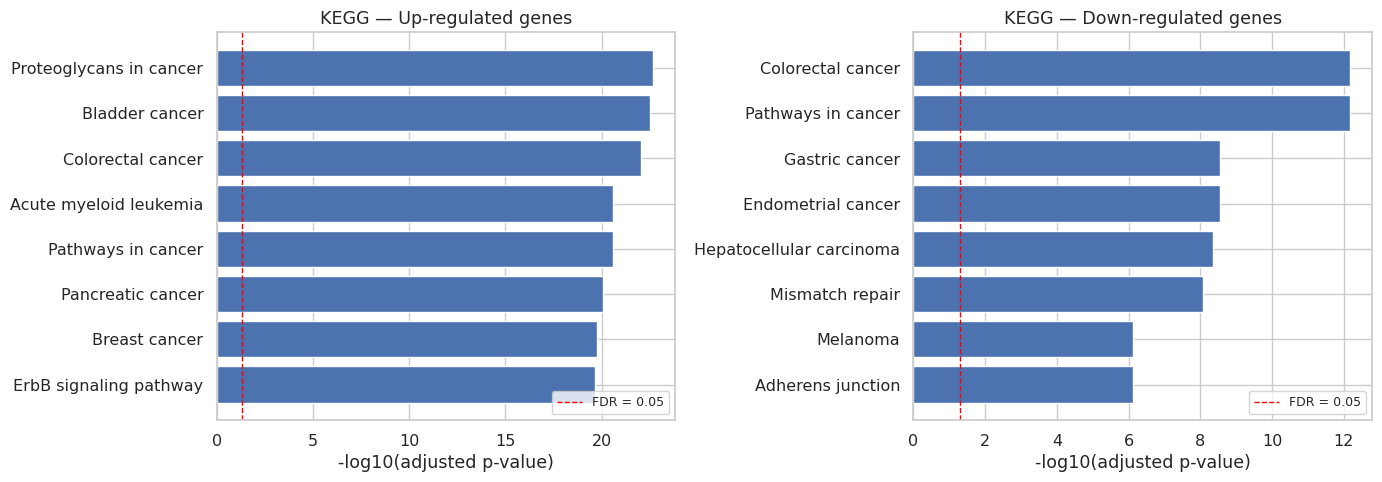

In [10]:
kegg_up = gp.enrichr(gene_list=up_genes, gene_sets="KEGG_2021_Human", organism="human", outdir=None).results
kegg_down = gp.enrichr(gene_list=down_genes, gene_sets="KEGG_2021_Human", organism="human", outdir=None).results

kegg_up = kegg_up.sort_values("Adjusted P-value")
kegg_down = kegg_down.sort_values("Adjusted P-value")

print("Top pathway UP in BRAF-mutant tumours:  ", kegg_up.iloc[0]["Term"])
print("Top pathway DOWN in BRAF-mutant tumours:", kegg_down.iloc[0]["Term"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
barplot_enrichment(kegg_up, "KEGG — Up-regulated genes", top_n=8, ax=axes[0])
barplot_enrichment(kegg_down, "KEGG — Down-regulated genes", top_n=8, ax=axes[1])
plt.tight_layout()
plt.show()


## 7. Exporting Results

Save the enrichment tables so they can be dropped straight into a supplementary materials file.

In [11]:
go_results["GO_Biological_Process_2023"].to_csv("GO_BP_enrichment.csv", index=False)
go_results["GO_Molecular_Function_2023"].to_csv("GO_MF_enrichment.csv", index=False)
go_results["GO_Cellular_Component_2023"].to_csv("GO_CC_enrichment.csv", index=False)
kegg_res.to_csv("KEGG_enrichment.csv", index=False)
print("Saved 4 CSV files to the working directory.")


Saved 4 CSV files to the working directory.


## 8. Lab Exercises

Answer the following in a short markdown cell (or a separate write-up) at the end of this notebook:

1. **Interpretation.** Name the top 3 significant KEGG pathways from Section 5. For each, state in one sentence why it makes biological sense (or doesn't) given that BRAF is a MAPK-pathway kinase.
2. **GO vs. KEGG.** GO Biological Process and KEGG both returned MAPK-signalling-related terms. What is the conceptual difference between what a GO term and a KEGG pathway represent?
3. **Multiple testing.** Explain, in your own words, why we use the **adjusted** p-value (FDR) rather than the raw p-value to rank enrichment results.
4. **Gene ratio vs. significance.** Find a term in your dot plot (Section 4.2) that has a *large* gene ratio but is *not* the most significant term. Why might a large-but-less-significant term still be biologically interesting?
5. **Extension task.** Modify Section 4 to also run `Reactome_2022` as a gene-set library and compare the top Reactome pathway to the top KEGG pathway. Are they concordant?
6. **Bring your own data.** Replace `deg_df` in Section 2 with a DEG table exported from your own DESeq2/edgeR analysis (columns: `gene_symbol`, `log2FoldChange`, `padj`) and re-run the whole notebook end-to-end.

## 9. Further Reading
- Ashburner et al. (2000), *Gene Ontology: tool for the unification of biology*, Nature Genetics.
- Kanehisa & Goto (2000), *KEGG: Kyoto Encyclopedia of Genes and Genomes*, Nucleic Acids Research.
- Chen et al. (2013), *Enrichr: interactive and collaborative HTML5 gene list enrichment analysis tool*, BMC Bioinformatics.
- gseapy documentation: https://gseapy.readthedocs.io/
